In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving suv_data.csv to suv_data.csv


In [3]:
dataset=pd.read_csv('suv_data.csv')
dataset.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [8]:
from pandas import get_dummies
sex=get_dummies(dataset['Gender'],drop_first=True).astype(int)
sex.head()

,Male
0,1
1,1
2,0
3,0
4,1


<Axes: >

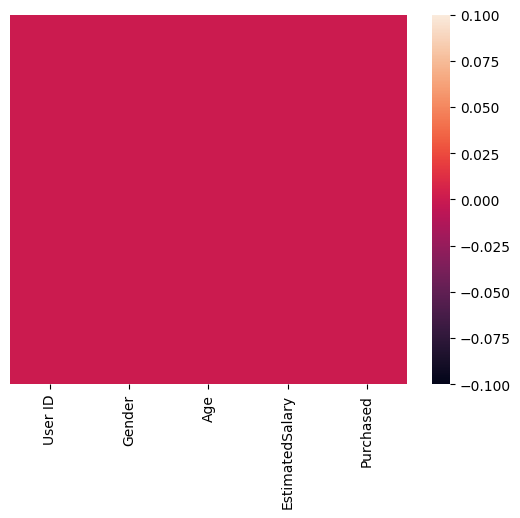

In [9]:
sns.heatmap(dataset.isnull(),yticklabels=False)

In [10]:
dataset=pd.concat([dataset,sex],axis=1)
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Male
0,15624510,Male,19,19000,0,1
1,15810944,Male,35,20000,0,1
2,15668575,Female,26,43000,0,0
3,15603246,Female,27,57000,0,0
4,15804002,Male,19,76000,0,1


In [11]:
dataset.drop(['Gender','User ID'],axis=1,inplace=True)
dataset.head()

,Age,EstimatedSalary,Purchased,Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [17]:
X = dataset[['Age', 'EstimatedSalary','Male']]
y = dataset['Purchased']

In [18]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [20]:
# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
# Prediction
y_pred = model.predict(X_test)

In [22]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.875
Confusion Matrix:
 [[47  5]
 [ 5 23]]


In [23]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()
model2.fit(X_train, y_train)


LogisticRegression()

In [24]:
pred2 = model2.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred2))

Accuracy: 0.8875
Confusion Matrix:
 [[50  2]
 [ 7 21]]


In [26]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred2))

Random Forest Accuracy: 0.875
Logistic Regression Accuracy: 0.8875
